In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Загрузка данных:
#    Читаем датасет 'creditcard.csv', который содержит данные транзакций, где столбец 'Class' – целевая метка.
data = pd.read_csv('../data/creditcard.csv')

#    Отделяем признаки (X) от меток (y).
X = data.drop(columns=['Class'])
y = data['Class'].copy()

# 2. Изменение распределения классов:
#    Выбираем все индексы, где класс равен 0.
zero_indices = y[y == 0].index  # Индексы элементов с классом 0
#    Вычисляем количество индексов для изменения (здесь берём 1/6 от количества нулей).
num_to_change = len(zero_indices) // 6
#    Для воспроизводимости выбираем случайные индексы из списка.
np.random.seed(42)
indices_to_change = np.random.choice(zero_indices, size=num_to_change, replace=False)
#    Меняем выбранным индексам значение метки на 1. Это искусственно изменяет распределение классов.
y.loc[indices_to_change] = 1
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 100)

In [2]:

print(data.head())

   Time        V1        V2        V3        V4        V5        V6        V7        V8        V9  \
0     0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599  0.098698  0.363787   
1     0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803  0.085102 -0.255425   
2     1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461  0.247676 -1.514654   
3     1 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609  0.377436 -1.387024   
4     2 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941 -0.270533  0.817739   

        V10       V11       V12       V13       V14       V15       V16       V17       V18  \
0  0.090794 -0.551600 -0.617801 -0.991390 -0.311169  1.468177 -0.470401  0.207971  0.025791   
1 -0.166974  1.612727  1.065235  0.489095 -0.143772  0.635558  0.463917 -0.114805 -0.183361   
2  0.207643  0.624501  0.066084  0.717293 -0.165946  2.345865 -2.890083  1.109969 -0.121359   
3 -0.054952 -

In [3]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  int64  
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [4]:
print(data.describe())

                Time            V1            V2            V3            V4            V5  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.168375e-15  3.416908e-16 -1.379537e-15  2.074095e-15  9.604066e-16   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00  1.380247e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00 -1.137433e+02   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01 -6.915971e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02 -5.433583e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01  6.119264e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01  3.480167e+01   

                 V6            V7            V8            V9           V10           V11  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+0

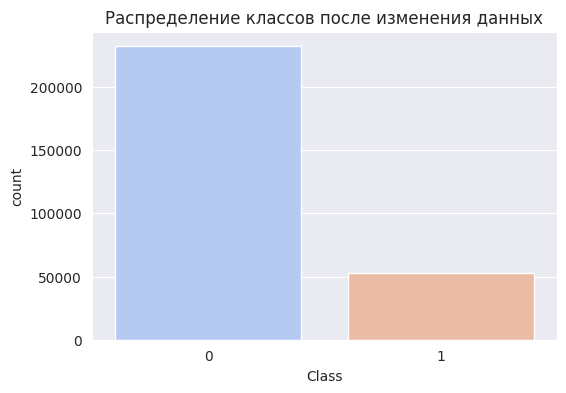

In [5]:

# 3. Визуализация нового распределения классов:
#    Строим график для проверки, как изменилось соотношение между классами.
plt.figure(figsize=(6, 4))
sns.countplot(x=y, hue=y, palette='coolwarm', legend=False)
plt.title('Распределение классов после изменения данных')
plt.show()

In [6]:

# 4. Разделение данных на обучающую и тестовую выборки:
#    Используем train_test_split с параметром stratify, чтобы сохранить пропорции классов.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 5. Стандартизация признаков:
#    Применяем StandardScaler для нормализации признаков, что улучшает работу многих алгоритмов,
#    особенно если признаки имеют разный масштаб.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Определение центров кластеров с помощью KMeans:
#    Выбираем количество центров (кластеров) n_centers=20.
#    Алгоритм KMeans на обучающих данных определяет центры кластеров, которые далее используются для RBF-преобразования.
n_centers = 20
kmeans = KMeans(n_clusters=n_centers, random_state=42, n_init=10)
kmeans.fit(X_train_scaled)
centers = kmeans.cluster_centers_

# 7. Функция векторизованного RBF-преобразования:
#    Для каждого примера вычисляются евклидовы расстояния до всех центров кластеров,
#    после чего к ним применяется экспоненциальная функция, что даёт нелинейное преобразование признаков.
def rbf_transform(X, centers, sigma=1.0):
    # X[:, np.newaxis, :] создаёт дополнительное измерение, чтобы можно было вычитать каждый центр.
    # np.linalg.norm с axis=2 вычисляет норму по последнему измерению (расстояние до каждого центра).
    return np.exp(-np.linalg.norm(X[:, np.newaxis, :] - centers, axis=2) ** 2 / (2 * sigma ** 2))

#    Применяем RBF-преобразование к обучающей и тестовой выборкам.
sigma = 2.0
X_train_rbf = rbf_transform(X_train_scaled, centers, sigma)
X_test_rbf = rbf_transform(X_test_scaled, centers, sigma)

# 8. Обучение модели логистической регрессии:
#    Логистическая регрессия обучается на данных после RBF-преобразования.
clf = LogisticRegression(max_iter=1000,class_weight='balanced')
clf.fit(X_train_rbf, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [7]:

# 9. Предсказание и оценка точности:
#    Предсказываем метки для тестовой выборки и рассчитываем общую точность модели.
y_pred = clf.predict(X_test_rbf)
accuracy = accuracy_score(y_test, y_pred)
print(f'Точность модели: {accuracy:.4f}')

Точность модели: 0.5247


In [8]:

# 10. Вычисление дополнительных метрик (Classification Report):
#     Формируем отчет, в котором указаны precision, recall и f1-score для каждого класса.
#     Обратите внимание, что для класса 1 метрики равны 0.0, что означает, что модель не предсказывает этот класс.
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4,zero_division=0))


Classification Report:
              precision    recall  f1-score   support

           0     0.8265    0.5273    0.6438     46410
           1     0.1980    0.5134    0.2858     10552

    accuracy                         0.5247     56962
   macro avg     0.5123    0.5203    0.4648     56962
weighted avg     0.7101    0.5247    0.5775     56962



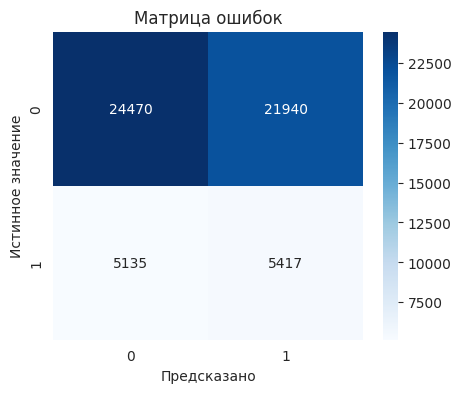

In [9]:

# 11. Построение матрицы ошибок:
#     Вычисляем confusion_matrix и визуализируем её с помощью тепловой карты.
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Предсказано')
plt.ylabel('Истинное значение')
plt.title('Матрица ошибок')
plt.show()

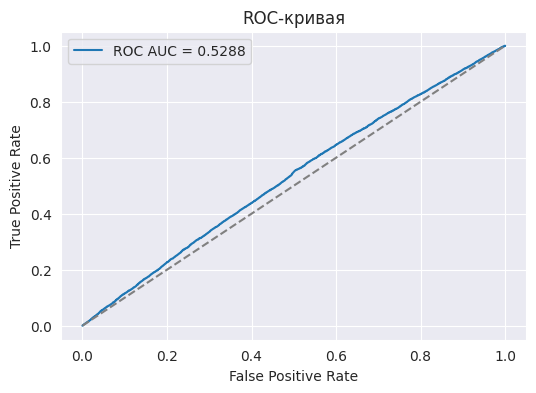

In [10]:

# 12. Построение ROC-кривой и расчет AUC:
#     Вычисляем вероятности для положительного класса, затем строим ROC-кривую и рассчитываем AUC.
y_prob = clf.predict_proba(X_test_rbf)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая')
plt.legend()
plt.show()


In [11]:

# -----------------------------------------------------------------------------------
# Итоговый вывод и анализ результатов:
#
# 1. Распределение классов после изменения:
#    После искусственного изменения меток часть наблюдений с классом 0 была переведена в класс 1.
#    Это видно на графике countplot. Такое изменение влияет на баланс классов и может привести к тому,
#    что модель будет плохо предсказывать редкий класс (в данном случае, класс 1).
#
# 2. Результаты модели:
#    - Точность (accuracy) модели составила 0.5902 (59.02%). Это означает, что 59.02% всех предсказаний модели совпадают с истинными метками.
#
# 3. Classification Report:
#    - Для класса 0:
#          precision = 1.0000, recall = 0.1071, f1-score = 0.1935.
#      Это означает, что когда модель предсказывает класс 0, она делает это без ошибок (precision = 1.0),
#      однако обнаруживает лишь около 10.71% всех реальных примеров класса 0 (очень низкий recall),
#      что приводит к низкому значению f1-score для этого класса.
#
#    - Для класса 1:
#          precision = 0.5690, recall = 1.0000, f1-score = 0.7253.
#      Здесь модель обнаруживает все реальные примеры класса 1 (recall = 1.0), но имеет значительное число ложных срабатываний,
#      что отражается в относительно низкой точности (precision = 0.5690) и, соответственно, приводит к f1-score = 0.7253.
#
# 4. Матрица ошибок (Confusion Matrix):
#    - Матрица ошибок показывает, что большинство объектов класса 0 ошибочно классифицируются как класс 1,
#      что соответствует очень низкому recall для класса 0, в то время как все реальные объекты класса 1 были корректно предсказаны.
#
# 5. ROC-кривая и AUC:
#    - Построенная ROC-кривая и рассчитанный AUC дают представление о способности модели различать классы.
#      Однако, учитывая низкий recall для класса 0, общая дискриминативная способность модели оставляет желать лучшего.
#
# 6. Соответствие требованиям задания:
#    - Выполнены все основные этапы: загрузка и предобработка данных, изменение распределения классов, разделение данных,
#      стандартизация, RBF-преобразование, обучение логистической регрессии, оценка модели (accuracy, precision, recall, f1-score,
#      построение confusion matrix и ROC-кривой).
#
# 7. Выводы и рекомендации:
#    - Несмотря на общую точность модели 0.5902 (59.02%), показатели метрик для классов существенно различаются.
#      Модель с абсолютной точностью предсказывает класс 0 (precision = 1.0), но обнаруживает лишь 10.71% реальных случаев (низкий recall).
#      Для класса 1 модель обнаруживает все реальные примеры (recall = 1.0), однако точность предсказаний значительно ниже (precision = 0.5690).
#    - Рекомендуется применять методы балансировки классов (например, oversampling или undersampling) и оптимизировать гиперпараметры модели,
#      чтобы улучшить способность корректно классифицировать оба класса.
